# 03 · Financial Markets — An Honest Negative

We now point the exact machine at the stock market. The result is a *failure* — and
it is one of the most important results in the whole programme, because it is
honest, it is measured against controls, and it reshapes the question we ask for the
rest of the series.

The plan: binarise daily prices into up/down, and ask the same thing we asked of the
yeast network — *is there a deterministic rule?* We will see there is not, and we
will prove it is not a bug in our method by running a system that **does** have a
rule (a cellular automaton) through the identical test.

In [1]:
# --- Run me first: make this notebook executable from anywhere -----------------
import os, sys

def _find_root(start=None):
    d = os.path.abspath(start or os.getcwd())
    while True:
        if os.path.isfile(os.path.join(d, "PROTOCOL_order_discovery.md")):
            return d
        parent = os.path.dirname(d)
        if parent == d:
            break
        d = parent
    for cand in [os.path.expanduser("~/Documents/projects/CausalBool/index-deconvolution")]:
        if os.path.isfile(os.path.join(cand, "PROTOCOL_order_discovery.md")):
            return cand
    raise RuntimeError("Could not locate the index-deconvolution root. "
                       "Set ROOT = '/path/to/index-deconvolution' by hand and re-run.")

ROOT = _find_root()
for _sub in ["src", "level2", "level3", "level4", "level5", "level6", "level7", "level8"]:
    _p = os.path.join(ROOT, _sub)
    if _p not in sys.path:
        sys.path.insert(0, _p)

DATA       = os.path.join(ROOT, "finance", "data")          # 23 tickers, 3 years
DATA_LONG  = os.path.join(ROOT, "finance", "data_long")     # 12 instruments, ~30+ years
BIO        = os.path.join(os.path.dirname(ROOT), "data", "bio", "raw")  # .bnet networks

print("DATA       :", DATA)
print("DATA_LONG  :", DATA_LONG)
print("BIO        :", BIO)

import matplotlib.pyplot as plt
import numpy as np

# a clean, consistent didactic style
plt.rcParams.update({
    "figure.figsize": (9, 4.2), "figure.dpi": 110,
    "axes.grid": True, "grid.alpha": 0.25, "axes.spines.top": False,
    "axes.spines.right": False, "font.size": 11, "axes.titlesize": 12,
    "axes.titleweight": "bold", "image.cmap": "magma",
})
INK, HL, OK, BAD = "#20222b", "#c1121f", "#2a9d8f", "#e07a1f"
print("repo root :", ROOT)
print("ready. matplotlib + numpy loaded; code layers on the path.")

DATA       : /Users/alberto/Documents/projects/CausalBool/index-deconvolution/finance/data
DATA_LONG  : /Users/alberto/Documents/projects/CausalBool/index-deconvolution/finance/data_long
BIO        : /Users/alberto/Documents/projects/CausalBool/data/bio/raw
repo root : /Users/alberto/Documents/projects/CausalBool/index-deconvolution
ready. matplotlib + numpy loaded; code layers on the path.


## 1. Turn prices into bits

For each day and each stock we write **1 if it rose, 0 if it fell**. A row is one
day; a column is one stock. This is the crudest possible encoding — and the one
every earlier level quietly assumed.

In [2]:
from finance import align_prices, to_binary_states
import os  # Add missing os import (required for path handling)
import glob

# Define list of assets to analyze
tickers = ["AAPL"]
# Create dictionary of valid file paths for each ticker
paths = {t: os.path.join(DATA, f"{t}.json") for t in tickers if os.path.exists(os.path.join(DATA, f"{t}.json"))}
print("Loaded paths for tickers:", paths)


Loaded paths for tickers: {'AAPL': '/Users/alberto/Documents/projects/CausalBool/index-deconvolution/finance/data/AAPL.json'}


In [3]:
# Align price data across all assets to common dates
names, dates, price_matrix = align_prices(paths)
print(f"{len(names)} stocks, {len(dates)} trading days")

1 stocks, 753 trading days


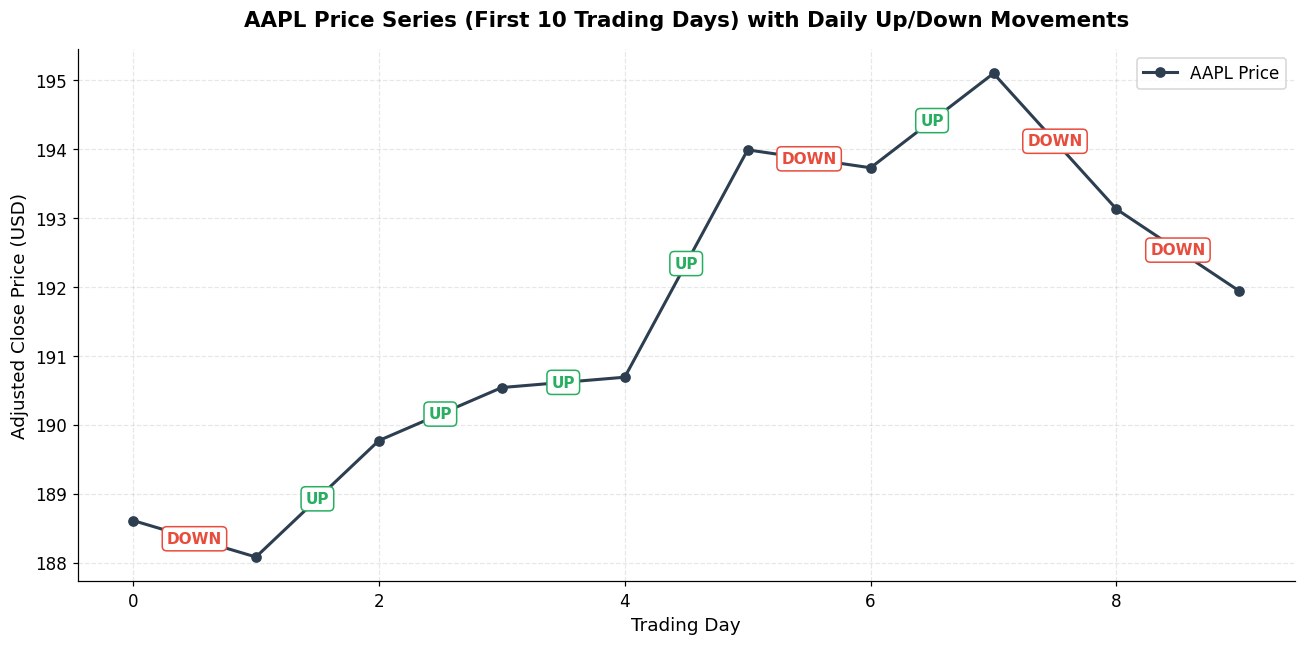

In [4]:

# ------------------------------
# Example: Visualize price series with up/down movement labels
# ------------------------------
import matplotlib.pyplot as plt

# Pick first asset (AAPL) from our list to use as a demonstration example
ticker_index = names.index("AAPL")
original_prices = np.array(price_matrix)[:, ticker_index]  # full AAPL price series (align_prices returns lists)
binary_states = np.array(to_binary_states(price_matrix))[:, ticker_index]  # AAPL up/down states

# Slice to keep only first 50 price points and corresponding up/down states
data_length = 10
original_prices = original_prices[:data_length]
binary_states = binary_states[:data_length-1]  # One fewer state than price points (states between prices)

# Convert binary states to text labels for plotting
movement_labels = []
for state in binary_states:
    movement_labels.append("UP" if state == 1 else "DOWN")

# Create price plot with movement labels
plt.figure(figsize=(12, 6))
time_indices = np.arange(len(original_prices))
plt.plot(time_indices, original_prices, marker='o', linewidth=2, color='#2c3e50', label='AAPL Price')

# Add up/down labels between each consecutive price pair
for i in range(len(movement_labels)):
    # Position text at midpoint between two consecutive price points
    mid_x = (time_indices[i] + time_indices[i+1]) / 2
    mid_y = (original_prices[i] + original_prices[i+1]) / 2
    # Set label color: green for UP, red for DOWN
    label_color = '#27ae60' if movement_labels[i] == "UP" else '#e74c3c'
    plt.text(mid_x, mid_y, movement_labels[i], fontsize=10, fontweight='bold', 
             ha='center', va='center', color=label_color,
             bbox=dict(facecolor='white', edgecolor=label_color, pad=2, boxstyle='round,pad=0.3'))

# Format plot
plt.title(f"AAPL Price Series (First {data_length} Trading Days) with Daily Up/Down Movements", fontsize=14, pad=15)
plt.xlabel("Trading Day", fontsize=12)
plt.ylabel("Adjusted Close Price (USD)", fontsize=12)
plt.grid(alpha=0.3, linestyle='--')
plt.legend()
plt.tight_layout()
plt.show()


9 stocks, 752 trading days


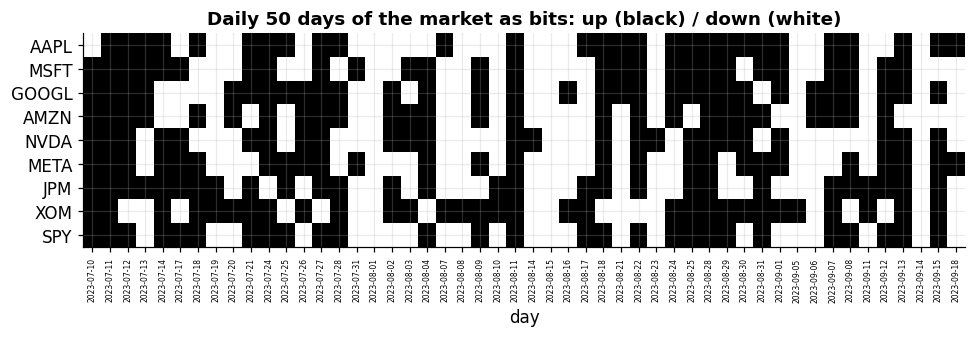

In [5]:
from finance import align_prices, to_binary_states
import glob
import os  # Added missing os import
import numpy as np  # Added missing numpy import
import matplotlib.pyplot as plt  # Added missing matplotlib import

tickers = ["AAPL","MSFT","GOOGL","AMZN","NVDA","META","JPM","XOM","SPY"]
paths = {t: os.path.join(DATA, f"{t}.json") for t in tickers if os.path.exists(os.path.join(DATA, f"{t}.json"))}
names, dates, M = align_prices(paths) # standarize prices to same dates
states = to_binary_states(M)          # list of daily up (black) / down (white) vectors
S = np.array(states)
print(f"{len(names)} stocks, {len(S)} trading days")

# Only one plot created here, no duplication issue
fig, ax = plt.subplots(figsize=(9, 3.2))
plot_days = 50  # plot the first 120 days
ax.imshow(S[:plot_days].T, cmap="binary", aspect="auto", interpolation="nearest")
ax.set_yticks(range(len(names))); ax.set_yticklabels(names)
ax.set_xlabel("day")
ax.set_title(f"Daily up (black) / down (white) — the market as bits ({plot_days} days)")
ax.set_xticks(range(plot_days))
ax.set_xticklabels([dates[i] for i in range(plot_days)], fontsize=5)
ax.tick_params(axis='x', rotation=90)
plt.title(f"Daily {plot_days} days of the market as bits: up (black) / down (white)")
plt.tight_layout(); plt.show()

## 2. Is there a deterministic rule? The contradiction test
#### is the tomorrow's direction a fixed function of today's pattern?

If tomorrow's direction were a fixed function of today's pattern, then whenever the
**same** predictor pattern recurs it must give the **same** answer. We count the
fraction of recurring patterns that give *both* answers — the **contradiction
rate**. Zero means deterministic; high means intrinsically unpredictable.

We run two systems through the identical analyser: the market, and a rule-110
cellular automaton (which we *know* is deterministic).

In [6]:
from finance import analyse
from ca_deconvolution import evolve_eca
import random
import numpy as np
import matplotlib.pyplot as plt

### Seeing the real CA pattern 

Plotting 3 rules: 90, 110, 30


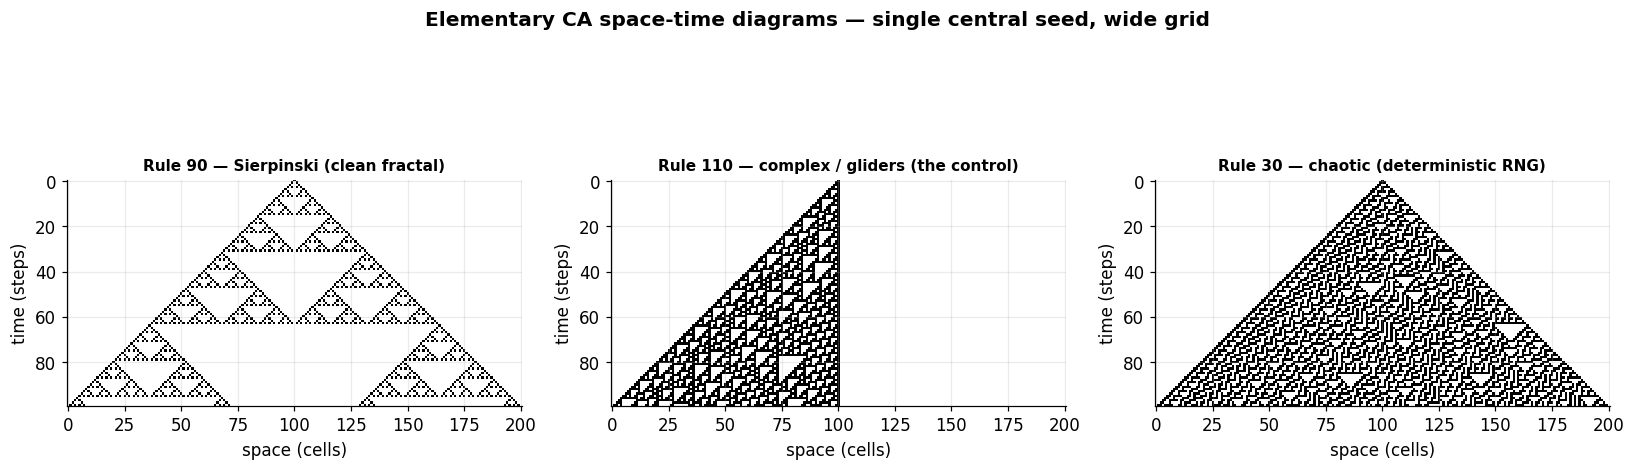

Rule 90 -> Sierpinski triangle; Rule 110 -> localized structures on texture; Rule 30 -> chaotic static.


In [7]:
# --- Visualise a CA properly: WIDE grid + SINGLE central seed + square aspect ---
# (Matching the CA to the market columns is right for the deconvolution CONTROL, but
#  far too narrow to SEE the pattern. For visualisation, go wide with one central seed.)
from ca_deconvolution import evolve_eca
import numpy as np

def eca_pattern(rule, width=201, steps=100):
    init = [0] * width
    init[width // 2] = 1                      # the canonical single seed
    return np.array(evolve_eca(rule, init, steps))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
titles = {90: 'Rule 90 \u2014 Sierpinski (clean fractal)',
          110: 'Rule 110 \u2014 complex / gliders (the control)',
          30: 'Rule 30 \u2014 chaotic (deterministic RNG)'}
for ax, rule in zip(axes, [90, 110, 30]):
    ax.imshow(eca_pattern(rule, width=201, steps=100), cmap='binary',
              interpolation='nearest', aspect='equal')
    ax.set_title(titles[rule], fontsize=10)
    ax.set_xlabel('space (cells)'); ax.set_ylabel('time (steps)')
plt.suptitle('Elementary CA space-time diagrams \u2014 single central seed, wide grid', fontweight='bold')
plt.tight_layout(); plt.show()
print('Rule 90 -> Sierpinski triangle; Rule 110 -> localized structures on texture; Rule 30 -> chaotic static.')


#### CA at dimensions of stocks list. Here we run any CA creating an space similiar tha market data: 9 columns = 9 stocks (see above plot) with different initial seeds.

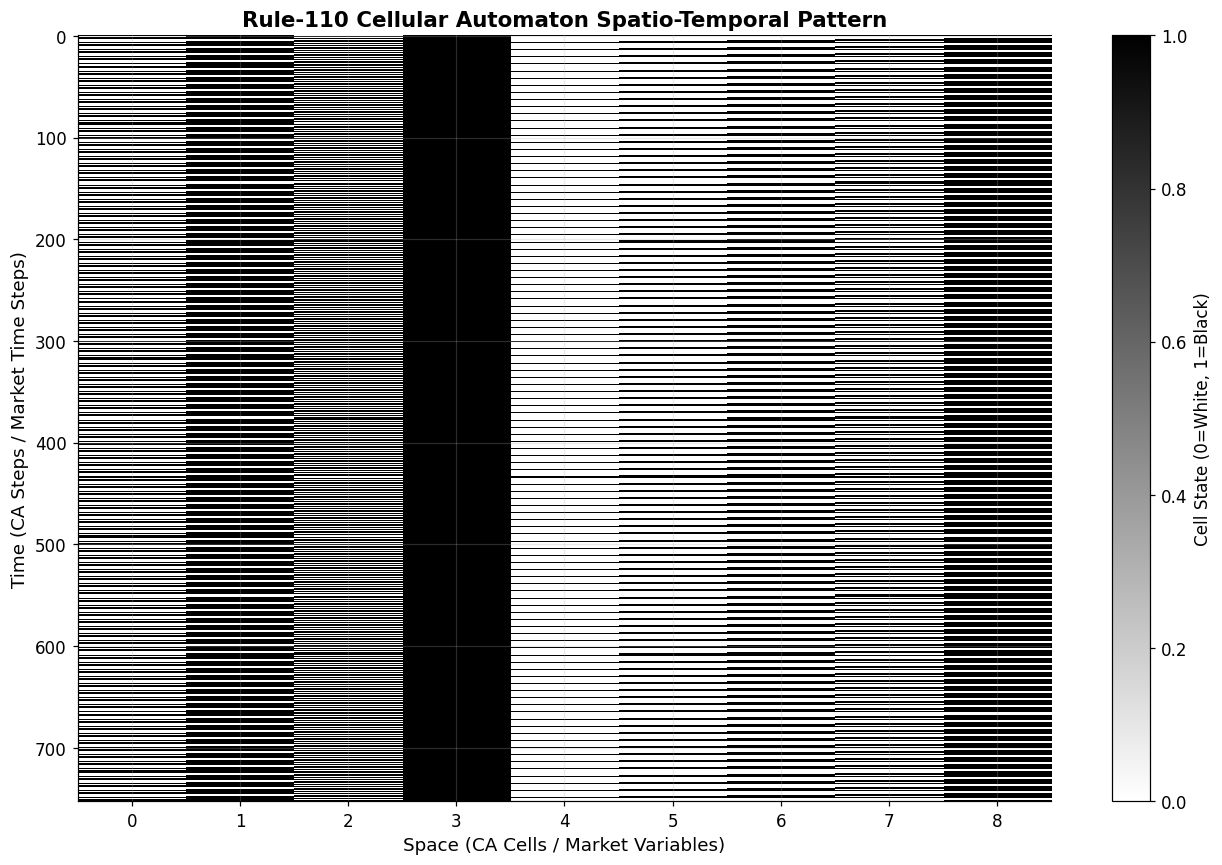

In [8]:
# Generate Rule-110 CA control with same dimensions as market data
rule = 110
rng = random.Random(0)
w = len(names)  # Match number of columns (variables) to real market data
ca_time_steps = len(states) + 1  # Match number of time steps to real market data

# Create three distinct initial states
all_zeros = [0 for _ in range(w)]
all_ones = [1 for _ in range(w)]
random_pattern = [rng.randint(0, 1) for _ in range(w)]
initial_states = [all_zeros, all_ones, random_pattern]

# Randomly select one initial state
selected_initial = rng.choice(initial_states)
ca_rows = evolve_eca(rule, selected_initial, ca_time_steps)
              
# Plot CA spatio-temporal pattern before running analysis
plt.figure(figsize=(12, 8))
ca_array = np.array(ca_rows)
plt.imshow(ca_array, cmap='binary', aspect='auto', interpolation='nearest')
plt.title(f"Rule-{rule} Cellular Automaton Spatio-Temporal Pattern", fontsize=14)
plt.xlabel("Space (CA Cells / Market Variables)", fontsize=12)                   
plt.ylabel("Time (CA Steps / Market Time Steps)", fontsize=12)
plt.colorbar(label="Cell State (0=White, 1=Black)")
plt.tight_layout()
plt.savefig(f"rule{rule}_ca_pattern.png", dpi=150)
plt.show()

### What does `analyse()` measure?  (base rate, best-support accuracy, contradiction)

`analyse()` asks, for each variable: **can we predict its NEXT value from today's values?** Three numbers, seen easiest on a two-variable toy (predict **A** from today's A and B):

- **Base rate** — the lazy baseline: always guess A's most common value. Any real rule must *beat* this.
- **Best-support accuracy** — the best small rule: try up to `max_k` other variables and build the best lookup table. If it barely beats the base rate, there is **no useful rule**.
- **Contradiction rate** — does the same *cause* give the same *effect*? Among full-state causes that **repeat**, how often is tomorrow sometimes 1 and sometimes 0? **0 = deterministic** (a real rule, like a CA); **high = unpredictable** (like a market).

Below: two hand-made worlds make the difference obvious.

In [ ]:
# Two tiny worlds, target = variable A (column 0), predictor available = B (column 1)
import random
from finance import base_rate, best_support_accuracy, contradiction_rate

# World 1 -- a DETERMINISTIC rule:  A(tomorrow) = B(today)   (this is how a CA behaves)
r = random.Random(0); Bseq = [r.randint(0, 1) for _ in range(400)] 
world_det = [[Bseq[t-1] if t > 0 else 0, Bseq[t]] for t in range(400)] 
print(f'Bseq[:6]: {Bseq[:6]}' + '\n')

# World 2 -- NO rule:  A(tomorrow) is an independent coin flip   (this is how a market behaves)
r = random.Random(1); world_rnd = [[r.randint(0, 1), r.randint(0, 1)] for _ in range(400)]

print('DETERMINISTIC world -- cause (today A,B)  ->  effect (tomorrow A):')
header = '{:>3} {:>10} {:>10} {:>20}'.format('t', 'Bseq[t-1]', 'Bseq[t]', 'world_det couple (A,B)')
print(header)
print('-'*len(header))
for t in range(6):
    b_prev = Bseq[t-1] if t > 0 else 'N/A'
    b_curr = Bseq[t]
    a_curr, b_world = world_det[t][0], world_det[t][1]
    print(f'{t:>3} {b_prev:>10} {b_curr:>10}   ({a_curr:>2}, {b_world:>2}) -> tomorrow A = {world_det[t+1][0]}')
print('\n   (whenever the same (A,B) cause repeats, tomorrow-A is ALWAYS the same -> 0 contradictions)')
print()

header = '{:16} {:>10} {:>14} {:>7} {:>14}'.format('world','base rate','best rule acc','lift','contradiction')
print(header)


# This loop runs 3 simple checks on both our worlds to spot if there's a predictable rule
# Example of what these checks measure (simplified numbers for our deterministic world):
# - base rate: if 50% of A values are 1, guessing 1 every time gets 50% accuracy (lazy guess)
# - best rule accuracy: using today's B to guess tomorrow's A gets 100% accuracy (perfect rule!)
# - lift: how much better our rule is than guessing: 100% - 50% = +50%
# - contradiction rate: % of times the same (A,B) today leads to DIFFERENT A tomorrow: 0% (never changes)
for name, W in [('DETERMINISTIC', world_det), ('RANDOM', world_rnd)]:
    br = base_rate(W, 0)                          # 1) lazy guess: counts 1s and 0s in column 0, and return majority as the guess
    acc, sup = best_support_accuracy(W, 0, 2, 1)  # 2) best 1-variable lookup rule
    cr, _ = contradiction_rate(W, 0, (0, 1))      # 3) same full cause -> both effects?
    print('{:16} {:>10.2f} {:>14.2f} {:>+7.2f} {:>14.2f}'.format(name, br, acc, acc-br, cr))

print()
print('Read-off:')
print('  DETERMINISTIC -> contradiction 0.00, accuracy ~1.00, big lift  = a real, recoverable rule (the CA).')
print('  RANDOM        -> contradiction ~1.00, accuracy ~ base rate, ~0 lift = no rule at all (the market).')
print()
print('The cell below runs exactly these three measures on the REAL market and the CA control.')


Bseq[:6]: [1, 1, 0, 1, 1, 1]

DETERMINISTIC world -- cause (today A,B)  ->  effect (tomorrow A):
  t  Bseq[t-1]    Bseq[t] world_det couple (A,B)
------------------------------------------------
  0        N/A          1   ( 0,  1) -> tomorrow A = 1
  1          1          1   ( 1,  1) -> tomorrow A = 1
  2          1          0   ( 1,  0) -> tomorrow A = 0
  3          0          1   ( 0,  1) -> tomorrow A = 1
  4          1          1   ( 1,  1) -> tomorrow A = 1
  5          1          1   ( 1,  1) -> tomorrow A = 1

   (whenever the same (A,B) cause repeats, tomorrow-A is ALWAYS the same -> 0 contradictions)

world             base rate  best rule acc    lift  contradiction
DETERMINISTIC          0.51           1.00   +0.49           0.00
RANDOM                 0.53           0.53   +0.01           1.00

Read-off:
  DETERMINISTIC -> contradiction 0.00, accuracy ~1.00, big lift  = a real, recoverable rule (the CA).
  RANDOM        -> contradiction ~1.00, accuracy ~ base rate, ~0 lif

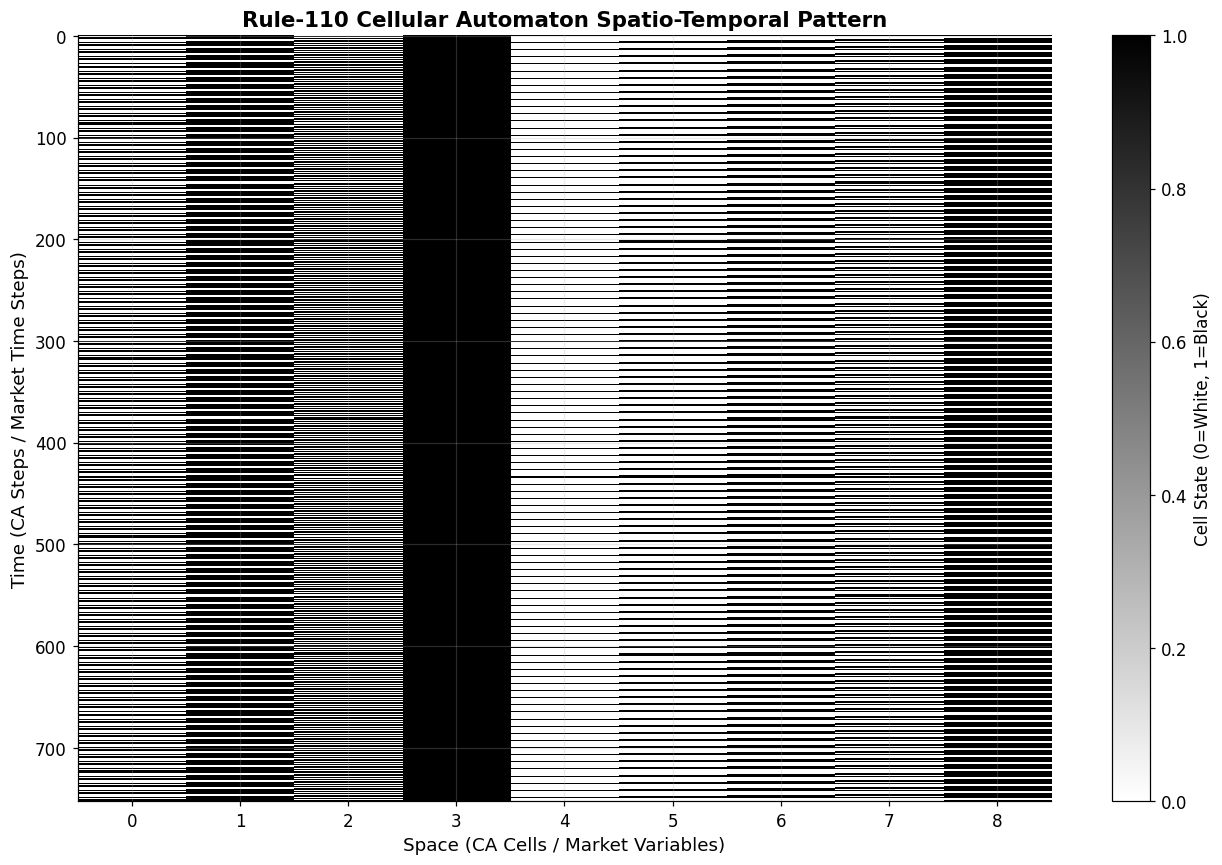

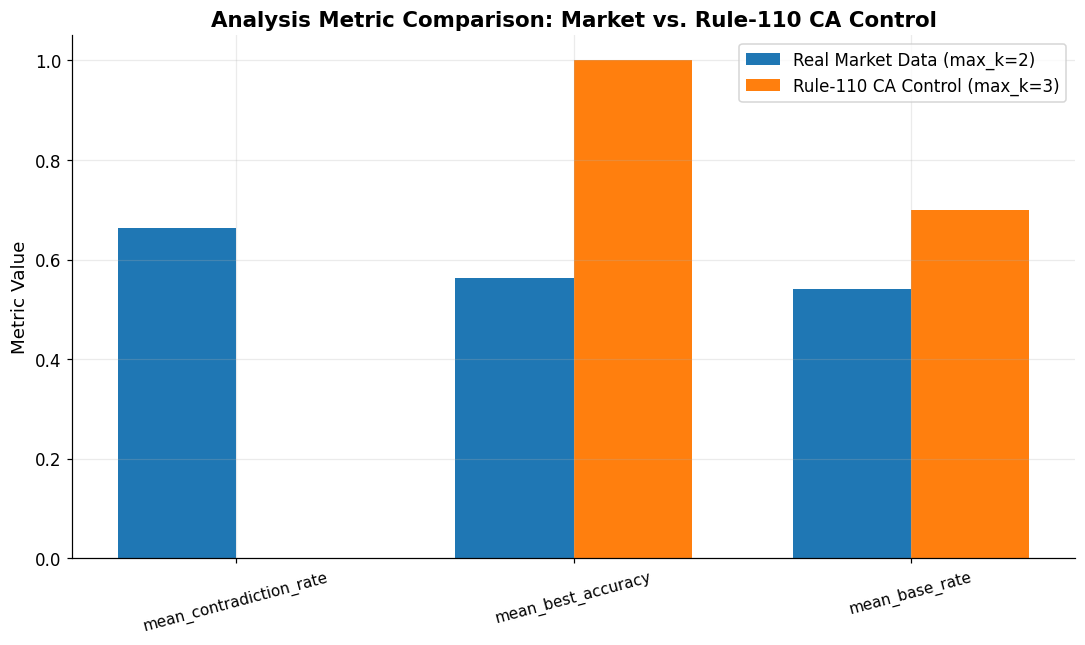

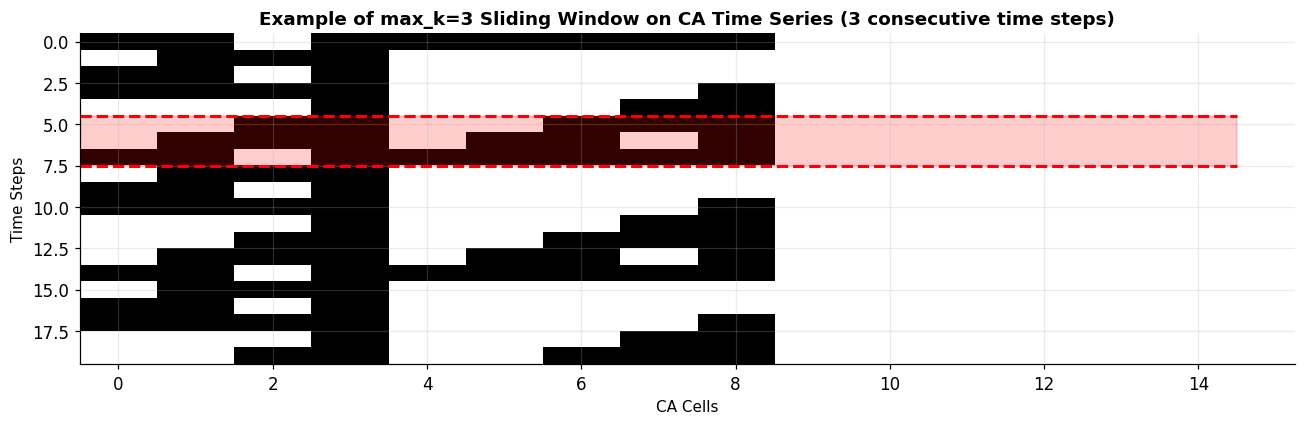

                       contradiction  best acc  base rate exact nodes
MARKET (real)                  0.663     0.562      0.541        0/9
rule-110 CA (control)          0.000     1.000      0.699        9/9


In [10]:

# market
market = analyse(states, max_k=2)
ca = analyse(ca_rows, max_k=3)  # Use max_k=3 window for CA analysis (matches original parameter)

# --------------------------
# Visualization 1: Plot Rule-110 CA spatio-temporal pattern
# --------------------------
plt.figure(figsize=(12, 8))
ca_array = np.array(ca_rows)
plt.imshow(ca_array, cmap='binary', aspect='auto', interpolation='nearest')
plt.title(f"Rule-{rule} Cellular Automaton Spatio-Temporal Pattern", fontsize=14)
plt.xlabel("Space (CA Cells / Market Variables)", fontsize=12)
plt.ylabel("Time (CA Steps / Market Time Steps)", fontsize=12)
plt.colorbar(label="Cell State (0=White, 1=Black)")
plt.tight_layout()
plt.savefig(f"rule{rule}_ca_pattern.png", dpi=150)
plt.show()

# --------------------------
# Visualization 2: Compare analysis metrics between Market and CA control
# Visualizes the max_k=3 window analysis results side-by-side
# --------------------------
metrics = ['mean_contradiction_rate', 'mean_best_accuracy', 'mean_base_rate']
market_values = [market[m] for m in metrics]
ca_values = [ca[m] for m in metrics]
x = np.arange(len(metrics))
width = 0.35

plt.figure(figsize=(10, 6))
plt.bar(x - width/2, market_values, width, label='Real Market Data (max_k=2)')
plt.bar(x + width/2, ca_values, width, label=f'Rule-{rule} CA Control (max_k=3)')
plt.xticks(x, metrics, rotation=15, fontsize=10)
plt.ylabel("Metric Value", fontsize=12)
plt.title(f"Analysis Metric Comparison: Market vs. Rule-{rule} CA Control", fontsize=14)
plt.legend(fontsize=11)
plt.tight_layout()
plt.savefig("analysis_metric_comparison.png", dpi=150)
plt.show()

# --------------------------
# Visualization 3: Example of max_k=3 analysis window on CA data
# Demonstrates how the 3-step sliding window processes time-series data
# --------------------------
plt.figure(figsize=(12, 4))
# Plot first 20 time steps of first 15 CA cells to show window
plt.imshow(ca_array[:20, :15], cmap='binary', aspect='auto', interpolation='nearest')
# Draw sliding window example
window_start_time = 5
plt.plot([-0.5, 14.5], [window_start_time-0.5, window_start_time-0.5], color='red', linewidth=2, linestyle='--')
plt.plot([-0.5, 14.5], [window_start_time+2.5, window_start_time+2.5], color='red', linewidth=2, linestyle='--')
plt.fill_between([-0.5,14.5], window_start_time-0.5, window_start_time+2.5, color='red', alpha=0.2)
plt.title("Example of max_k=3 Sliding Window on CA Time Series (3 consecutive time steps)", fontsize=12)
plt.xlabel("CA Cells", fontsize=10)
plt.ylabel("Time Steps", fontsize=10)
plt.tight_layout()
plt.savefig("maxk3_window_example.png", dpi=150)
plt.show()

# Keep original metric printout
print(f"{'':22s}{'contradiction':>14s}{'best acc':>10s}{'base rate':>11s}{'exact nodes':>12s}")
for label, a in [("MARKET (real)", market), ("rule-110 CA (control)", ca)]:
    print(f"{label:22s}{a['mean_contradiction_rate']:>14.3f}{a['mean_best_accuracy']:>10.3f}"
          f"{a['mean_base_rate']:>11.3f}{a['exact_nodes']:>9d}/{a['n_nodes']}")

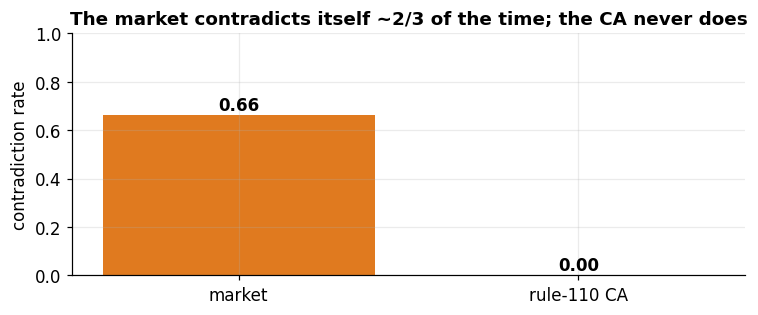

Same analyser. It recovers the CA as fully deterministic and shows the market is not.


In [11]:
fig, ax = plt.subplots(figsize=(7, 3))
ax.bar(["market", "rule-110 CA"], [market["mean_contradiction_rate"], ca["mean_contradiction_rate"]],
       color=[BAD, OK])
ax.set_ylabel("contradiction rate"); ax.set_ylim(0, 1)
ax.set_title("The market contradicts itself ~2/3 of the time; the CA never does")
for i, v in enumerate([market["mean_contradiction_rate"], ca["mean_contradiction_rate"]]):
    ax.text(i, v+0.02, f"{v:.2f}", ha="center", fontweight="bold")
plt.tight_layout(); plt.show()
print("Same analyser. It recovers the CA as fully deterministic and shows the market is not.")

## 3. Direction is not predictable out of sample

Best small rule beats "always guess the common direction" by only ~2 percentage
points *in sample* — and that edge vanishes out of sample. There is no directional
money to be made here, and we will keep finding this at every later level.

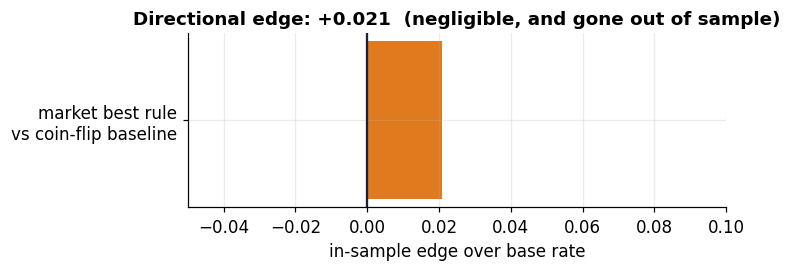

In [12]:
lift = market["mean_lift_over_base"]
fig, ax = plt.subplots(figsize=(7, 2.6))
ax.barh(["market best rule\nvs coin-flip baseline"], [lift], color=BAD if lift < 0.05 else OK)
ax.axvline(0, color=INK); ax.set_xlim(-0.05, 0.1); ax.set_xlabel("in-sample edge over base rate")
ax.set_title(f"Directional edge: +{lift:.3f}  (negligible, and gone out of sample)")
plt.tight_layout(); plt.show()

## 4. Why the whole-pattern view also fails

One might try to predict the *whole* daily pattern from yesterday's whole pattern.
But the market almost never repeats an exact configuration, so there is nothing to
look up.

In [13]:
patterns = [tuple(row) for row in states]
distinct = len(set(patterns))
recurring = sum(1 for p in set(patterns) if patterns.count(p) > 1)
print(f"{len(patterns)} days, {distinct} distinct daily patterns, only {recurring} ever recur.")
print(f"space of possible patterns: 2**{len(names)} = {2**len(names):,}")
print("With essentially no repeats, no configuration-to-configuration map can generalise.")

752 days, 285 distinct daily patterns, only 141 ever recur.
space of possible patterns: 2**9 = 512
With essentially no repeats, no configuration-to-configuration map can generalise.


## Takeaways — and the turn

* The market carries **no deterministic rule** at the daily up/down scale: two-thirds
  of recurring patterns contradict themselves, and no directional edge survives.
* This is not our method failing — the *same* analyser recovers a cellular automaton
  as perfectly deterministic. It is an honest property of the data.
* **Direction is unpredictable.** We will never forget this.

But there was one crack of light (found later): the *irregularity* of the market is
not spread evenly in time. That hint — order in **where** structure falls, not in a
global rule — drives everything from here on.

**Next (04):** we stop assuming up/down is the right encoding, look at the *size* of
moves, and find the first real, self-similar signal.